# Mathematical Programming Review in gurobipy

`gurobipy` is the Python API for Gurobi, one of the most powerful and efficient mathematical optimization solvers available on the market. Gurobi is widely used in operations research, combinatorial optimization, and mathematical programming to solve problems such as:

- Linear Programming (LP)
- Mixed-Integer Programming (MIP)
- Quadratic Programming (QP)
- Mixed-Integer Quadratic Programming (MIQP)
- Nonlinear Programming with quadratic constraints (MIQCP)

## Reference links

- Gurobi Manual: https://docs.gurobi.com/projects/optimizer/en/current/
- Gurobi website: https://www.gurobi.com/

# Session Learning Objective

Introduce and review the use of `gurobipy` to solve mathematical programming problems.

In [1]:
# Install required 3P libraries
%pip install gurobipy
from gurobipy import Model, GRB, quicksum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 41.8 MB/s eta 0:00:00


In [2]:
# Create model
m = Model("Example")

# Define variables
x = m.addVar(vtype=GRB.CONTINUOUS, name="x")
y = m.addVar(vtype=GRB.CONTINUOUS, name="y")

# Define constraints
m.addConstr(2 * x + y <= 10, name="c1")
m.addConstr(x + 3 * y <= 12, name="c2")

# Define objective function
m.setObjective(3 * x + 4 * y, GRB.MAXIMIZE)

# Solve model
m.optimize()

# Display solutions
for v in m.getVars():
    print(f"{v.varName} = {v.x}")

print(f"Optimal value: {m.objVal}")

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros (Max)
Model fingerprint: 0x3293e776
Model has 2 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [3e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]

Presolve time: 0.01s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.0000000e+30   2.500000e+30   7.000000e+00      0s
       2    2.2000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.200000000e+01
x = 3.6
y = 2.8
Optimal value: 22.0


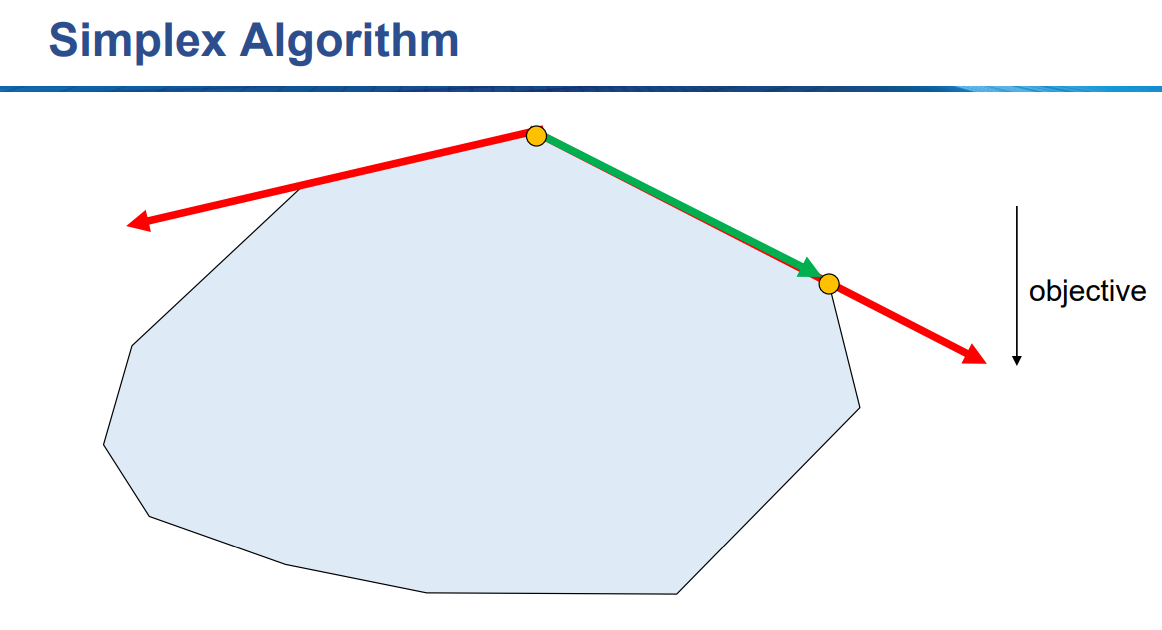

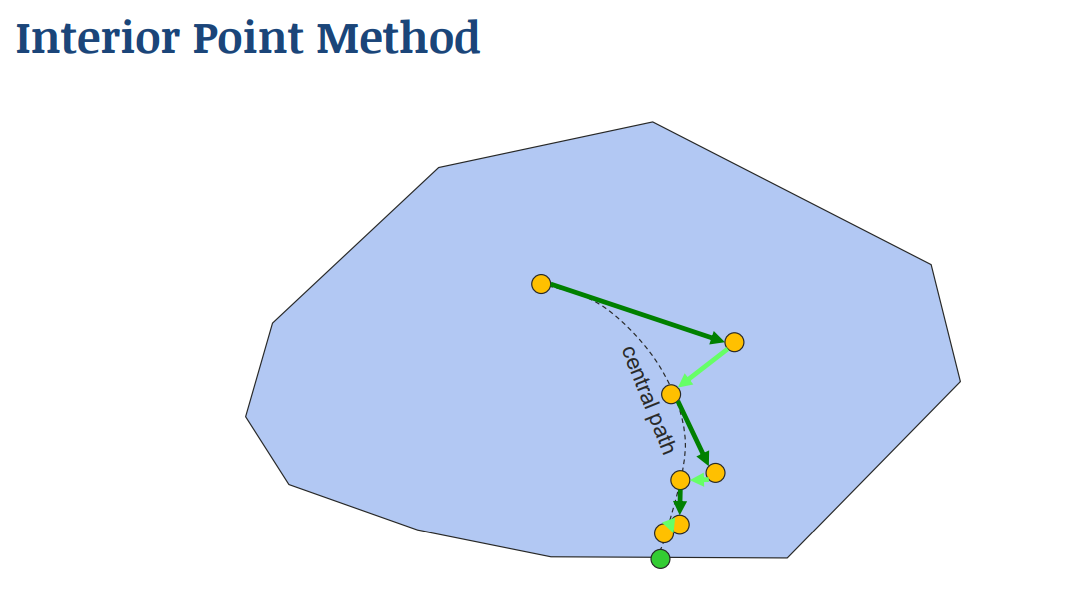

In [3]:
# Create model
m = Model("Example")

# Define variables
x = m.addVar(vtype=GRB.INTEGER, name="x")
y = m.addVar(vtype=GRB.CONTINUOUS, name="y")

# Define constraints
m.addConstr(2 * x + y <= 10, name="c1")
m.addConstr(x + 3 * y <= 12, name="c2")

# Define objective function
m.setObjective(3 * x + 4 * y, GRB.MAXIMIZE)

# Solve model
m.optimize()

# Display solutions
for v in m.getVars():
    print(f"{v.varName} = {v.x}")

print(f"Optimal value: {m.objVal}")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros (Max)
Model fingerprint: 0x3296a1b0
Model has 2 linear objective coefficients
Variable types: 1 continuous, 1 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [3e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+01]

Found heuristic solution: objective 15.0000000
Presolve time: 0.00s
Presolved: 2 rows, 2 columns, 4 nonzeros
Variable types: 0 continuous, 2 integer (0 binary)

Root relaxation: objective 2.200000e+01, 2 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   22.000

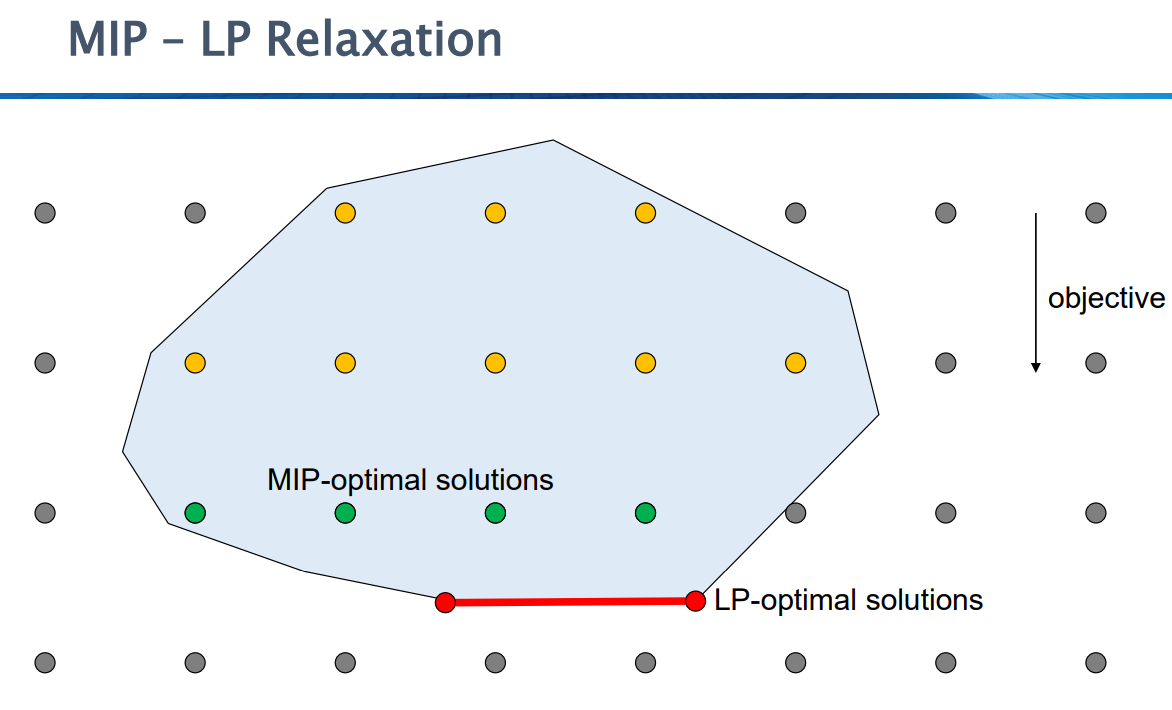

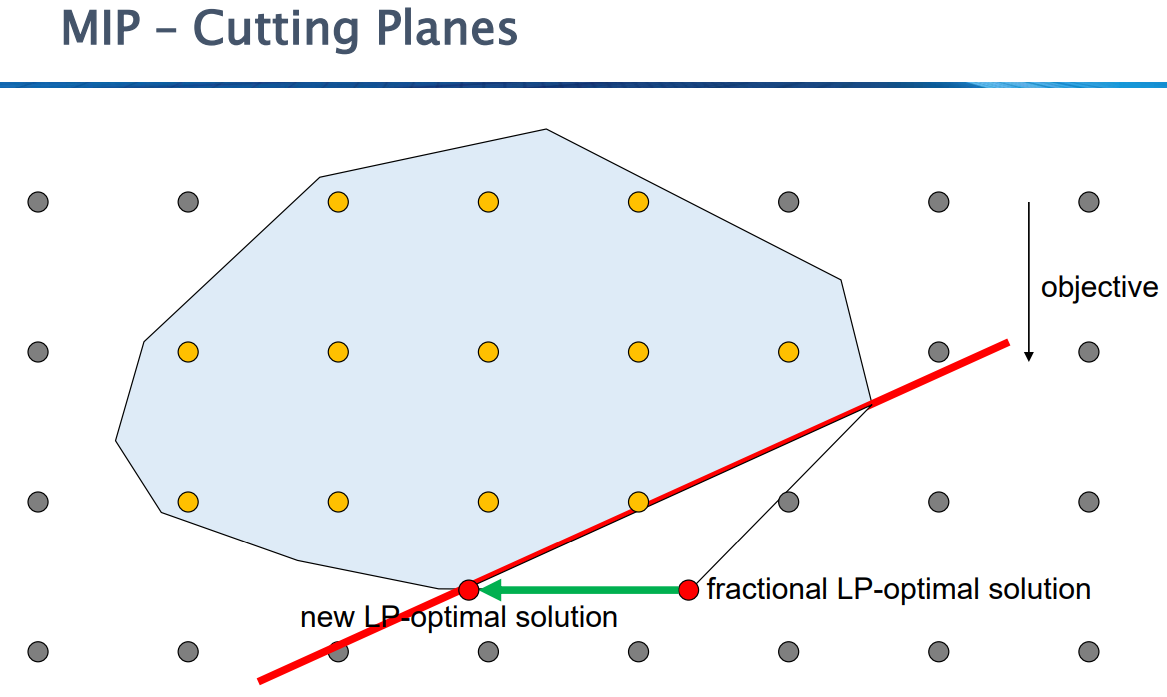

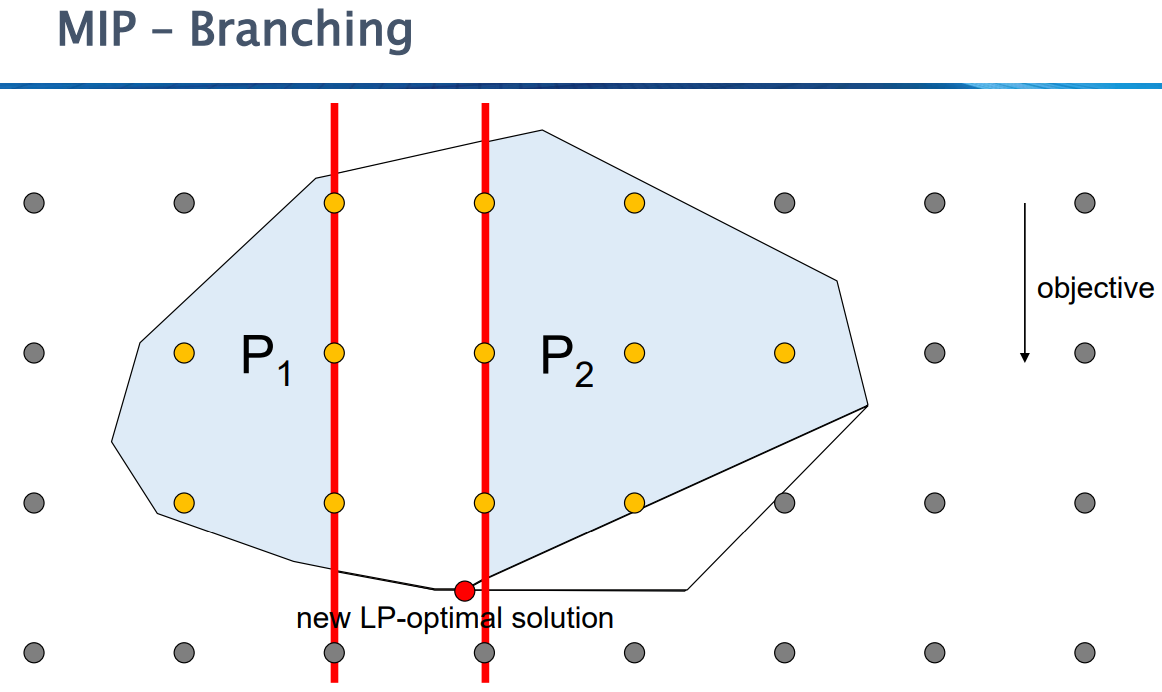

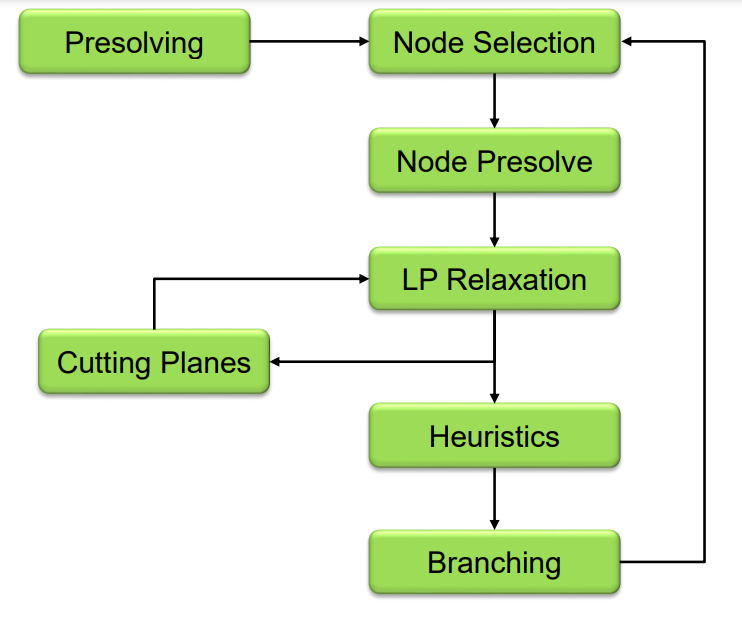

# How simplex works in LP

In [ ]:
!pip install gilp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 1.5 MB/s eta 0:00:00
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=e6af44af894612e65e66d907f41bfc19f62cd9556d5ce047554d8d202fdf55f6
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


In [ ]:
from gilp.visualize import simplex_visual
from gilp.simplex import LP
import numpy as np

In [ ]:
A = np.array([[0, 1, -1],
              [1, -1, 1],
              [1, 0, 1],
              [2, -1, 0]])
b = np.array([[4],
              [2],
              [3],
              [0]])
c = np.array([[1],
              [2],
              [3]])
# Alternatively
#b = np.array([4,2,3,0])
#c = np.array([1,2])

lp = LP(A,b,c)

In [ ]:
simplex_visual(lp).show()

In [ ]:
A1 = np.array([[2, 1,],
              [1, 3]])
b1 = np.array([[10],
              [12]])
c1 = np.array([[3],
              [4]])

lp1 = LP(A1,b1,c1)
simplex_visual(lp1).show()